# System Load 多样性分析

## 这个 notebook 要回答什么

前面 `check_split_overlap.ipynb` 发现：
- 33-bus 数据集有 17520 行**互不相同**的 `system_load` 输入
- 但所有 17520 行的最优拓扑 `target_open` 只对应 **87 种不同值**
- 平均每种拓扑被 17520/87 ≈ 200 行复用

**核心疑问**：负荷一直在变，为什么最优拓扑变化这么少？是不是负荷变化幅度太小，导致最优解只在少数情况下切换？

## 数据背景（已通过论文 + 数据反推确认）

- 负荷来源：UK Power Networks「Low Carbon London」项目，伦敦 5567 户家庭的智能电表数据（2011/11 – 2014/02，半小时分辨率）
- 单位：每户家庭整户用电（不是单个家电）
- 17520 = 365 × 48 = 全年每半小时一个时间点
- 映射到节点的方式（论文未公开，从数据反推）：每个 bus 似乎对应**不同的住户群曲线**（不同 CoV）+ **基准缩放**（不同均值），但所有 bus 共享同一类日周期（节点间相关 ~0.79）
- 求解器：MATPOWER + Mishra et al. 2017 的启发式分支交换法

## 分析模块

- **B**：每 bus 的 P/Q 描述统计（变化幅度有多大）
- **C**：时间维度的负荷曲线（日周期 / 年周期）
- **D**：节点间相关性（是否共享系统因子）
- **F**：**拓扑 ↔ 负荷映射**（核心）—— 把负荷降到 2D 看每个拓扑对应负荷空间的哪个区域


In [1]:
import ast
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from sklearn.decomposition import PCA

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 30)
plt.rcParams['figure.dpi'] = 90

# === 中文字体设置 ===
# matplotlib 默认 DejaVu Sans 不含 CJK 字符，导致图里中文显示成方块。
# 在 macOS 上挨个尝试常见 CJK 字体，第一个能找到的就用它。
_candidates = ['PingFang SC', 'Heiti SC', 'STHeiti', 'Songti SC',
               'Arial Unicode MS', 'Hiragino Sans GB', 'Microsoft YaHei',
               'Noto Sans CJK SC', 'WenQuanYi Micro Hei']
_available = {f.name for f in matplotlib.font_manager.fontManager.ttflist}
for _f in _candidates:
    if _f in _available:
        plt.rcParams['font.sans-serif'] = [_f] + plt.rcParams['font.sans-serif']
        plt.rcParams['axes.unicode_minus'] = False  # 顺手修负号被显示成方块
        print(f'中文字体: 使用 {_f!r}')
        break
else:
    print('⚠️ 找不到 CJK 字体，图里的中文会显示方块；可手动加字体或改英文。')

DATASET_ROOT = Path('/Users/town/Codes/RL4DistReconfig/Dataset')
UNPROCESSED = DATASET_ROOT / 'Unprocessed'
NETWORKS = [33, 37, 69, 84, 136]

for n in NETWORKS:
    p = UNPROCESSED / f'samples_{n}bus.csv'
    print(f'  {p.name:25s}  exists={p.exists()}')

中文字体: 使用 'STHeiti'
  samples_33bus.csv          exists=True
  samples_37bus.csv          exists=True
  samples_69bus.csv          exists=True
  samples_84bus.csv          exists=True
  samples_136bus.csv         exists=True


In [2]:
# system_load 字段是字符串 '[0j, (0.0333+0.02j), ...]'，要解析回复数列表
def parse_complex_list(s: str):
    return [complex(v) for v in ast.literal_eval(s)]


# updated_open_lines 字段是字符串 '[(8, 21), (9, 15), ...]'。
# 同一组拓扑可能写成 (a,b) 也可能写成 (b,a)，列表顺序也可能不同，
# 所以做规范化：每条边内部 sort、整条列表 sort，然后转 tuple 当 key
def canonical_open_lines(s: str):
    edges = ast.literal_eval(s)
    return tuple(sorted(tuple(sorted(e)) for e in edges))


_data_cache = {}

def load_network(n_bus: int):
    """返回 (df, P, Q)，P/Q 形状为 (rows, n_bus) 的实数数组。
    P = 有功，Q = 无功，单位是 MVA 标幺值。
    """
    if n_bus in _data_cache:
        return _data_cache[n_bus]
    df = pd.read_csv(UNPROCESSED / f'samples_{n_bus}bus.csv')
    arr = np.array(df['system_load'].apply(parse_complex_list).tolist())
    df = df.reset_index(drop=True)
    _data_cache[n_bus] = (df, arr.real, arr.imag)
    return _data_cache[n_bus]


# 主分析以 33-bus 为锚
df33, P33, Q33 = load_network(33)
print(f'33-bus 数据集: {len(df33)} 行 × {P33.shape[1]} bus')
print(f'17520 = 365 × 48 = {365*48} (全年每半小时)：', len(df33) == 365 * 48)

33-bus 数据集: 17520 行 × 33 bus
17520 = 365 × 48 = 17520 (全年每半小时)： True


## 模块 B：每 bus 的负荷描述统计

回答"每个节点的负荷波动有多大"。

关键指标：
- `P_mean` / `Q_mean`：均值（节点的"基准负荷"）
- `P_std`：标准差
- `P_CoV` = std/mean：**变异系数**，相对波动幅度。CoV=0.1 → 变化幅度约 10%；CoV=0.5 → 变化非常剧烈
- `P_max/P_min`：峰谷比，最高负荷是最低的几倍

如果各 bus 的 CoV **大致相同**，说明所有 bus 都被同一条全网负荷因子缩放（每个 bus 共享同一条曲线）。
如果 CoV **差异显著**，说明每个 bus 对应**不同的住户群**（不同曲线）。

In [3]:
stats33 = pd.DataFrame({
    'bus': np.arange(1, 34),
    'P_min': P33.min(0), 'P_max': P33.max(0),
    'P_mean': P33.mean(0), 'P_std': P33.std(0),
    'Q_mean': Q33.mean(0), 'Q_std': Q33.std(0),
})
stats33['P_CoV'] = stats33['P_std'] / stats33['P_mean'].replace(0, np.nan)
stats33['P_peak_trough_ratio'] = stats33['P_max'] / stats33['P_min'].replace(0, np.nan)
print('33-bus 每 bus 的负荷统计（P = 有功）：\n')
print(stats33.round(4).to_string(index=False))
print()
print('—— 关键观察 ——')
nz = stats33[stats33['P_mean'] > 0]
print(f'  bus 1 (slack) P_mean = {stats33.loc[0, "P_mean"]}（应为 0）')
print(f'  非 slack bus P_mean 范围: [{nz["P_mean"].min():.4f}, {nz["P_mean"].max():.4f}]'
      f'  (比值 {nz["P_mean"].max()/nz["P_mean"].min():.1f}× —— 不同 bus 基准负荷差异)')
print(f'  非 slack bus P_CoV 范围: [{nz["P_CoV"].min():.3f}, {nz["P_CoV"].max():.3f}]'
      f'  中位数 {nz["P_CoV"].median():.3f}')
print(f'  非 slack bus P_max/P_min 范围: [{nz["P_peak_trough_ratio"].min():.2f}, '
      f'{nz["P_peak_trough_ratio"].max():.2f}]  中位数 {nz["P_peak_trough_ratio"].median():.2f}')

33-bus 每 bus 的负荷统计（P = 有功）：

 bus  P_min  P_max  P_mean  P_std  Q_mean  Q_std  P_CoV  P_peak_trough_ratio
   1 0.0000  0.000  0.0000 0.0000  0.0000 0.0000    NaN                  NaN
   2 0.0180  0.120  0.0523 0.0172  0.0314 0.0103 0.3294               6.6667
   3 0.0112  0.108  0.0385 0.0135  0.0171 0.0060 0.3509               9.6429
   4 0.0224  0.144  0.0577 0.0188  0.0384 0.0126 0.3267               6.4286
   5 0.0146  0.072  0.0336 0.0089  0.0168 0.0045 0.2654               4.9315
   6 0.0147  0.072  0.0342 0.0111  0.0114 0.0037 0.3257               4.8980
   7 0.0376  0.240  0.1000 0.0354  0.0500 0.0177 0.3540               6.3830
   8 0.0246  0.240  0.0785 0.0324  0.0393 0.0162 0.4126               9.7561
   9 0.0104  0.072  0.0317 0.0091  0.0106 0.0030 0.2858               6.9231
  10 0.0122  0.072  0.0293 0.0090  0.0098 0.0030 0.3077               5.9016
  11 0.0076  0.054  0.0211 0.0068  0.0141 0.0045 0.3234               7.1053
  12 0.0124  0.072  0.0323 0.0094  0.0188 0.005

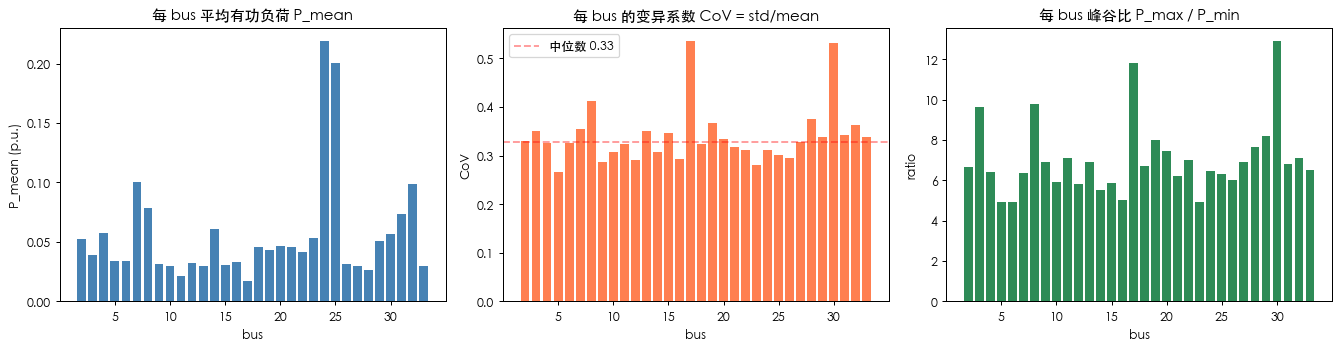

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
nz = stats33[stats33['P_mean'] > 0]

axes[0].bar(nz['bus'], nz['P_mean'], color='steelblue')
axes[0].set_title('每 bus 平均有功负荷 P_mean')
axes[0].set_xlabel('bus'); axes[0].set_ylabel('P_mean (p.u.)')

axes[1].bar(nz['bus'], nz['P_CoV'], color='coral')
axes[1].set_title('每 bus 的变异系数 CoV = std/mean')
axes[1].set_xlabel('bus'); axes[1].set_ylabel('CoV')
axes[1].axhline(nz['P_CoV'].median(), color='red', linestyle='--', alpha=0.4, label=f'中位数 {nz["P_CoV"].median():.2f}')
axes[1].legend()

axes[2].bar(nz['bus'], nz['P_peak_trough_ratio'], color='seagreen')
axes[2].set_title('每 bus 峰谷比 P_max / P_min')
axes[2].set_xlabel('bus'); axes[2].set_ylabel('ratio')

plt.tight_layout()
plt.show()

## 模块 C：时间维度的负荷曲线

假设原 CSV 按时间顺序排列（行 0 = 第 1 个半小时，行 i 在第 `i // 48` 天的第 `i % 48` 个半小时）。验证：
- 日周期：连续 7 天的曲线应该呈现 7 个相似的"双峰"或"单峰"
- 年周期：365 天的日均值是否呈现冬高夏低（伦敦居民冬天用电更多）
- 跨 bus 的日内 pattern 是否相似（验证模块 D 要进一步证明的"共享日周期"）

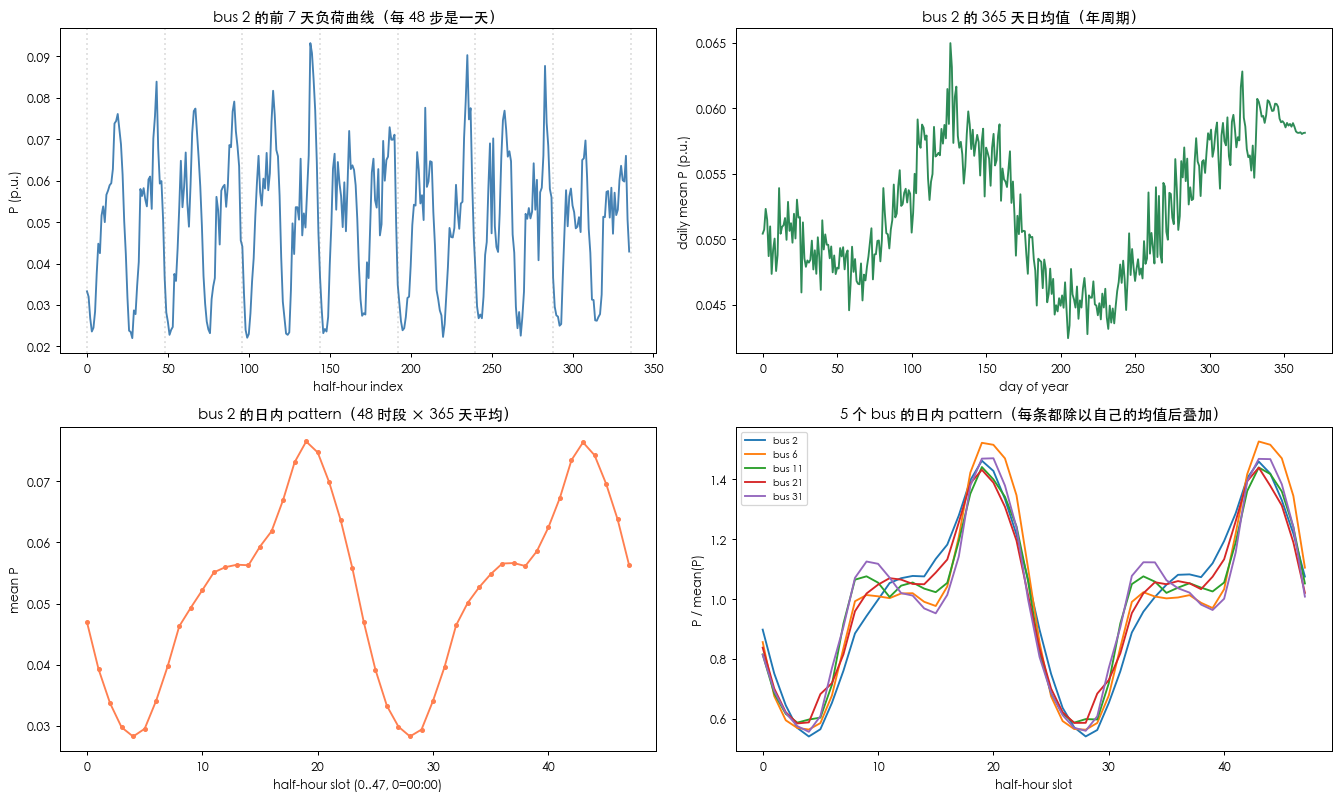

日内变化幅度 (max/min of mean curve):
  bus  2: 2.70×  (低谷 0.0283 → 高峰 0.0765)
  bus  6: 2.71×  (低谷 0.0193 → 高峰 0.0522)
  bus 11: 2.45×  (低谷 0.0124 → 高峰 0.0304)
  bus 21: 2.46×  (低谷 0.0264 → 高峰 0.0651)
  bus 31: 2.64×  (低谷 0.0411 → 高峰 0.1086)


In [5]:
# 形状变成 (365 天, 48 时段, 33 bus)
P_cube = P33.reshape(365, 48, 33)
daily_mean = P_cube.mean(axis=1)         # 每天的平均负荷 (365, 33)
hour_means = P_cube.mean(axis=0)         # 每个时段在全年的平均 (48, 33)

fig, axes = plt.subplots(2, 2, figsize=(15, 9))

# C-1. bus 2 前 7 天的逐半小时负荷
axes[0, 0].plot(P33[:7*48, 1], color='steelblue')
for d in range(8):
    axes[0, 0].axvline(d * 48, color='gray', alpha=0.25, linestyle=':')
axes[0, 0].set_title('bus 2 的前 7 天负荷曲线（每 48 步是一天）')
axes[0, 0].set_xlabel('half-hour index'); axes[0, 0].set_ylabel('P (p.u.)')

# C-2. bus 2 全年逐日均值
axes[0, 1].plot(daily_mean[:, 1], color='seagreen')
axes[0, 1].set_title('bus 2 的 365 天日均值（年周期）')
axes[0, 1].set_xlabel('day of year'); axes[0, 1].set_ylabel('daily mean P (p.u.)')

# C-3. bus 2 的日内 pattern（48 时段在 365 天上平均）
axes[1, 0].plot(hour_means[:, 1], color='coral', marker='o', markersize=3)
axes[1, 0].set_title('bus 2 的日内 pattern（48 时段 × 365 天平均）')
axes[1, 0].set_xlabel('half-hour slot (0..47, 0=00:00)'); axes[1, 0].set_ylabel('mean P')

# C-4. 5 个 bus 的日内 pattern 叠加（归一化）
for b in [1, 5, 10, 20, 30]:
    series = hour_means[:, b]
    axes[1, 1].plot(series / series.mean(), label=f'bus {b+1}')
axes[1, 1].set_title('5 个 bus 的日内 pattern（每条都除以自己的均值后叠加）')
axes[1, 1].set_xlabel('half-hour slot'); axes[1, 1].set_ylabel('P / mean(P)')
axes[1, 1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print('日内变化幅度 (max/min of mean curve):')
for b in [1, 5, 10, 20, 30]:
    s = hour_means[:, b]
    print(f'  bus {b+1:2d}: {s.max()/s.min():.2f}×  (低谷 {s.min():.4f} → 高峰 {s.max():.4f})')

## 模块 D：节点间相关性

如果所有 bus 共享同一类日周期，节点间的 Pearson 相关性应该很高（接近 1）。如果每个 bus 是独立的负荷曲线，相关性应该接近 0。

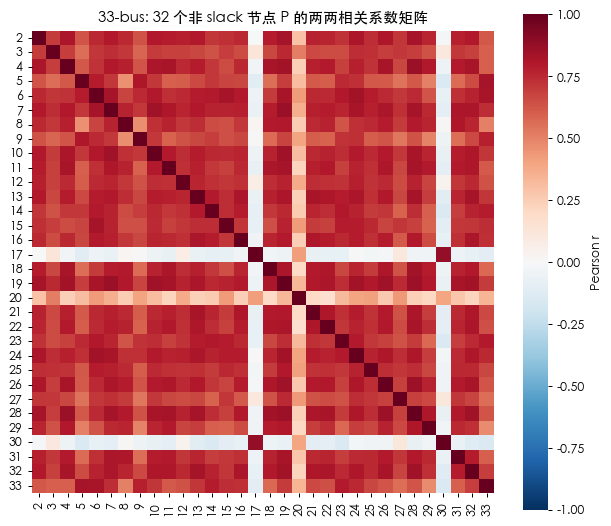

相关系数（每对节点一次，共 496 对）:
  均值:   0.615
  中位数: 0.725
  最小:   -0.155
  最大:   0.876

按相关性强度分桶:
  [+0.8, +1.0):   77 对 ( 15.5%) ███████
  [+0.6, +0.8):  307 对 ( 61.9%) ██████████████████████████████
  [+0.4, +0.6):   29 对 (  5.8%) ██
  [+0.2, +0.4):   23 对 (  4.6%) ██
  [-0.2, +0.2):   60 对 ( 12.1%) ██████
  [-1.0, -0.2):    0 对 (  0.0%) 
  合计 = 496/496 (应当等于 496)


In [6]:
# 排除 slack bus（bus 1 全 0）
P33_nz = P33[:, 1:]
corr = np.corrcoef(P33_nz.T)

fig, ax = plt.subplots(1, 1, figsize=(7, 6))
sns.heatmap(corr, ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1, square=True,
            xticklabels=range(2, 34), yticklabels=range(2, 34), cbar_kws={'label': 'Pearson r'})
ax.set_title('33-bus: 32 个非 slack 节点 P 的两两相关系数矩阵')
plt.tight_layout()
plt.show()

# 用 boolean mask 取真正的上三角元素（避免 triu 把下三角填 0 混淆分桶）
triu_mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
upper_values = corr[triu_mask]  # 长度 = 32*31/2 = 496

mean_r = upper_values.mean()
med_r = np.median(upper_values)
print(f'相关系数（每对节点一次，共 {len(upper_values)} 对）:')
print(f'  均值:   {mean_r:.3f}')
print(f'  中位数: {med_r:.3f}')
print(f'  最小:   {upper_values.min():.3f}')
print(f'  最大:   {upper_values.max():.3f}')
print()
print(f'按相关性强度分桶:')
total = 0
for lo, hi in [(0.8, 1.0), (0.6, 0.8), (0.4, 0.6), (0.2, 0.4), (-0.2, 0.2), (-1.0, -0.2)]:
    in_range = ((upper_values >= lo) & (upper_values < hi)).sum()
    pct = in_range / len(upper_values) * 100
    total += in_range
    bar = '█' * int(pct / 2)
    print(f'  [{lo:+.1f}, {hi:+.1f}): {in_range:4d} 对 ({pct:5.1f}%) {bar}')
print(f'  合计 = {total}/{len(upper_values)} (应当等于 {len(upper_values)})')

## 模块 F（核心）：拓扑 ↔ 负荷映射

回答最初的疑问。

步骤：
1. 每行有一个 `updated_open_lines`（最优拓扑 = label），规范化后作为分类 key
2. 17520 行 → 多少种拓扑？分布如何？头部覆盖率？
3. 每种拓扑对应的负荷空间长什么样？用 PCA 把 33 维负荷投到 2D，按拓扑染色

### F.0 先把"什么是同一个拓扑"定义清楚

每行的 `updated_open_lines` 字段是字符串，比如 `"[(14, 15), (32, 33), (7, 8), (25, 29), (9, 10)]"`。

这个字符串**不能直接当 label 比较**，因为同一组开断线在 CSV 里有多种等价写法：

1. **元组方向**：边 `(32, 33)` 和 `(33, 32)` 表示同一条线（无向图）
2. **列表顺序**：5 条开断线之间没有先后关系，`[(7,8), (14,15), ...]` 和 `[(14,15), (7,8), ...]` 是同一组
3. **格式空白**：少数行的逗号空格不同

如果按 raw 字符串直接 `nunique()`，上面三种情况会被算成 3 种不同的 label，把"拓扑多样性"严重高估。

**规范化（canonicalize）做两件事**：
- 每条边内部 sort：`(33, 32) → (32, 33)`
- 整组边 sort：得到一个固定顺序的边集合

规范化后用 tuple 当 dict key 就能精确比较\"两行是不是同一个拓扑\"。

下面这个 cell **先展示同一拓扑的多种 raw 写法**，再做规范化，看看 raw nunique 和 canonical nunique 差多少。

In [7]:
# 规范化函数 canonical_open_lines 已经在 parsers cell 里定义好了，复用即可。
# 这里把整个过程拆开演示一遍，方便对照。

raw_strings = df33['updated_open_lines']
print(f'raw 字符串 nunique:        {raw_strings.nunique()}')

# 做规范化
canonical = raw_strings.apply(canonical_open_lines)
print(f'canonical (tuple) nunique: {canonical.nunique()}')
print(f'压缩比:                    {raw_strings.nunique() / canonical.nunique():.1f}×')
print()

# 找一个被多种 raw 写法对应到同一个 canonical tuple 的真实例子
groups = {}
for r, c in zip(raw_strings, canonical):
    groups.setdefault(c, set()).add(r)

# 按"有多少种 raw 写法"排序，找压缩最厉害的一个
top_collapsed = sorted(groups.items(), key=lambda kv: len(kv[1]), reverse=True)[0]
canon_key, raw_variants = top_collapsed

print(f'举例: 同一组拓扑在 raw CSV 里有 {len(raw_variants)} 种不同的字符串写法')
print('=' * 80)
print('  raw 字符串变体（前 5 个）:')
for v in list(raw_variants)[:5]:
    print(f'    {v}')
if len(raw_variants) > 5:
    print(f'    ... 还有 {len(raw_variants) - 5} 种')
print()
print(f'  规范化后唯一表示 (canonical tuple):')
print(f'    {canon_key}')
print()
print('  这些 raw 字符串虽然看起来不同，但 (a) 边内部方向不同、(b) 边顺序不同，')
print('  规范化后被正确合并成一种拓扑。如果按 raw 字符串去 nunique，这一个拓扑就被算成', len(raw_variants), '种。')

raw 字符串 nunique:        103
canonical (tuple) nunique: 17
压缩比:                    6.1×

举例: 同一组拓扑在 raw CSV 里有 17 种不同的字符串写法
  raw 字符串变体（前 5 个）:
    [(14, 15), (7, 8), (9, 10), (25, 29), (33, 32)]
    [(33, 32), (14, 15), (7, 8), (9, 10), (25, 29)]
    [(14, 15), (32, 33), (7, 8), (25, 29), (9, 10)]
    [(14, 15), (7, 8), (25, 29), (9, 10), (32, 33)]
    [(14, 15), (33, 32), (7, 8), (9, 10), (25, 29)]
    ... 还有 12 种

  规范化后唯一表示 (canonical tuple):
    ((7, 8), (9, 10), (14, 15), (25, 29), (32, 33))

  这些 raw 字符串虽然看起来不同，但 (a) 边内部方向不同、(b) 边顺序不同，
  规范化后被正确合并成一种拓扑。如果按 raw 字符串去 nunique，这一个拓扑就被算成 17 种。


In [8]:
df33['topo'] = df33['updated_open_lines'].apply(canonical_open_lines)
sizes = df33['topo'].value_counts().sort_values(ascending=False)

print(f'33-bus: {len(df33)} 行 → {len(sizes)} 种不同的最优拓扑')
print(f'平均每种拓扑被 {len(df33)/len(sizes):.1f} 行复用\n')
print('每种拓扑出现次数分布:')
print(sizes.describe().round(1).to_string())
print()
cumcov = sizes.cumsum() / sizes.sum() * 100
for k in [1, 5, 10, 20, 50]:
    if k <= len(sizes):
        print(f'  前 {k:2d} 种拓扑覆盖: {cumcov.iloc[k-1]:5.1f}% 行 ({sizes.iloc[:k].sum()}/{len(df33)})')

33-bus: 17520 行 → 17 种不同的最优拓扑
平均每种拓扑被 1030.6 行复用

每种拓扑出现次数分布:
count      17.0
mean     1030.6
std      1901.1
min         2.0
25%        21.0
50%        96.0
75%      1267.0
max      6631.0

  前  1 种拓扑覆盖:  37.8% 行 (6631/17520)
  前  5 种拓扑覆盖:  91.5% 行 (16030/17520)
  前 10 种拓扑覆盖:  99.3% 行 (17405/17520)


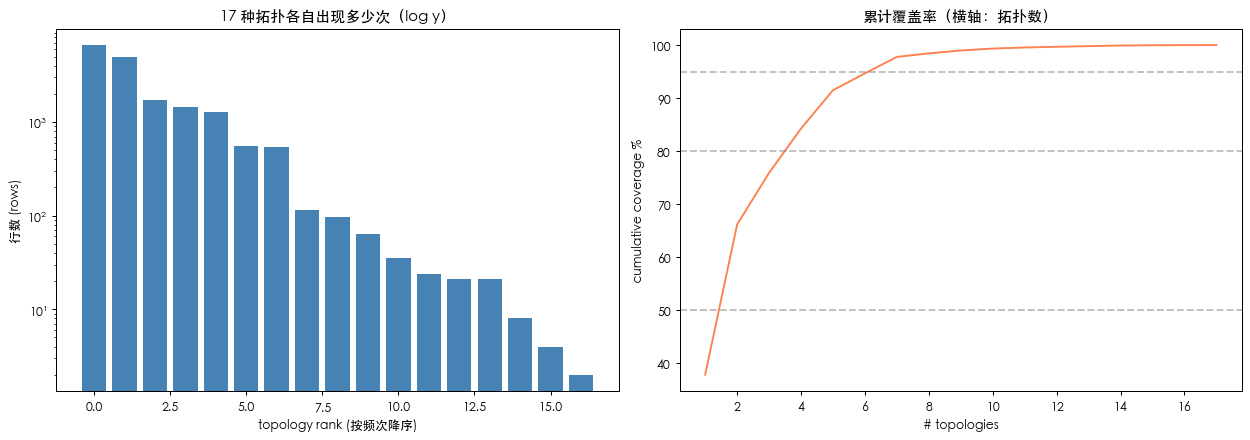

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(len(sizes)), sizes.values, color='steelblue')
axes[0].set_xlabel('topology rank (按频次降序)')
axes[0].set_ylabel('行数 (rows)')
axes[0].set_title(f'{len(sizes)} 种拓扑各自出现多少次（log y）')
axes[0].set_yscale('log')

axes[1].plot(range(1, len(sizes) + 1), cumcov.values, color='coral')
axes[1].axhline(50, color='gray', linestyle='--', alpha=0.5)
axes[1].axhline(80, color='gray', linestyle='--', alpha=0.5)
axes[1].axhline(95, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('# topologies'); axes[1].set_ylabel('cumulative coverage %')
axes[1].set_title('累计覆盖率（横轴：拓扑数）')

plt.tight_layout()
plt.show()

In [10]:
# 每行的系统总有功 total_P = sum over buses
total_P = P33.sum(axis=1)
df33['total_P'] = total_P

print(f'整个数据集 total_P: mean={total_P.mean():.3f}, std={total_P.std():.3f}, '
      f'range=[{total_P.min():.3f}, {total_P.max():.3f}], peak/trough={total_P.max()/total_P.min():.2f}×')
print()
print('Top 10 拓扑各自对应的 total_P 分布:')
print('-' * 90)
print(f'{"rank":>4} {"rows":>5} {"total_P_mean":>14} {"total_P_std":>13} {"total_P_min":>13} {"total_P_max":>13}')
top10 = sizes.head(10)
top10_ranges = []
for i, (t, n) in enumerate(top10.items()):
    tp = df33.loc[df33['topo'] == t, 'total_P']
    top10_ranges.append((i+1, n, tp.min(), tp.max()))
    print(f'{i+1:>4} {n:>5} {tp.mean():>14.3f} {tp.std():>13.3f} {tp.min():>13.3f} {tp.max():>13.3f}')

# === 真量化：Top 10 拓扑两两之间 total_P 区间的重叠率 ===
# overlap(A, B) = |[min,max] 区间交集长度| / max(|A|, |B|)
print()
print('Top 10 拓扑两两的 total_P 区间重叠率（交集长度 / 较大区间长度）:')
print('  100% = 完全包含，0% = 区间完全错开')
print('-' * 90)
def overlap_pct(a, b):
    lo = max(a[0], b[0]); hi = min(a[1], b[1])
    inter = max(0, hi - lo)
    larger = max(a[1] - a[0], b[1] - b[0])
    return inter / larger * 100 if larger > 0 else 0.0

ranges = [(r[2], r[3]) for r in top10_ranges]
header = '      ' + ' '.join(f'{j+1:>5}' for j in range(len(ranges)))
print(header)
for i in range(len(ranges)):
    row = f'  #{i+1:<2} '
    for j in range(len(ranges)):
        if i == j:
            row += '    - '
        else:
            row += f'{overlap_pct(ranges[i], ranges[j]):>5.0f} '
    print(row)

# 把上三角的重叠率拍平算统计
overlaps = [overlap_pct(ranges[i], ranges[j])
            for i in range(len(ranges)) for j in range(i+1, len(ranges))]
print()
print(f'共 {len(overlaps)} 对 (top-10 中两两):')
print(f'  重叠率均值:   {np.mean(overlaps):.1f}%')
print(f'  重叠率中位数: {np.median(overlaps):.1f}%')
print(f'  重叠率 >50% 的对数: {sum(1 for o in overlaps if o > 50)}/{len(overlaps)}')

整个数据集 total_P: mean=1.771, std=0.477, range=[0.852, 3.292], peak/trough=3.86×

Top 10 拓扑各自对应的 total_P 分布:
------------------------------------------------------------------------------------------
rank  rows   total_P_mean   total_P_std   total_P_min   total_P_max
   1  6631          1.813         0.481         0.852         3.292
   2  4962          1.812         0.493         0.858         3.224
   3  1707          1.754         0.502         0.868         3.172
   4  1463          1.727         0.458         0.874         3.095
   5  1267          1.643         0.422         0.871         3.073
   6   556          1.706         0.450         0.860         2.875
   7   544          1.525         0.275         0.976         2.067
   8   115          1.832         0.250         0.886         2.619
   9    96          1.782         0.247         0.944         2.840
  10    64          1.196         0.147         0.977         1.673

Top 10 拓扑两两的 total_P 区间重叠率（交集长度 / 较大区间长度）:
  100% = 完全

PCA 前 2 个主成分解释方差比例: 74.8% + 6.1% = 80.9%
  (PC1 = 32 维空间里那根"波动最大的轴"。如果接近 100% 说明负荷向量几乎在一条直线上 = 同比缩放)


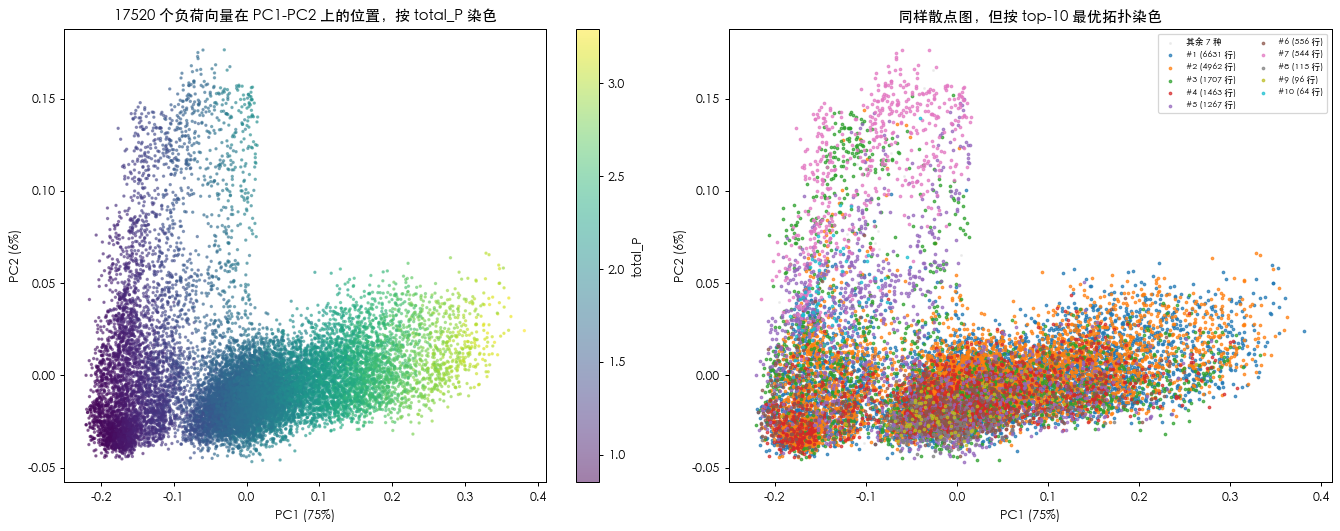


PC1-PC2 平面上 top-10 拓扑标签的 silhouette 分数: -0.376
  解读: >+0.5 高度聚类 / +0.2~+0.5 中等聚类 / 0~+0.2 弱聚类 / <0 几乎不分
  数据告诉我们这个值是 -0.376，自己判断是哪一档


In [11]:
# 33 维负荷向量降到 2D（排除 slack 后 32 维）
from sklearn.metrics import silhouette_score

pca = PCA(n_components=2)
P_pca = pca.fit_transform(P33_nz)
print(f'PCA 前 2 个主成分解释方差比例: {pca.explained_variance_ratio_[0]*100:.1f}% + '
      f'{pca.explained_variance_ratio_[1]*100:.1f}% = '
      f'{pca.explained_variance_ratio_[:2].sum()*100:.1f}%')
print(f'  (PC1 = 32 维空间里那根"波动最大的轴"。如果接近 100% 说明负荷向量几乎在一条直线上 = 同比缩放)')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 左：按 total_P 染色
sc = axes[0].scatter(P_pca[:, 0], P_pca[:, 1], c=total_P, cmap='viridis', s=3, alpha=0.5)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.0f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.0f}%)')
axes[0].set_title('17520 个负荷向量在 PC1-PC2 上的位置，按 total_P 染色')
plt.colorbar(sc, ax=axes[0], label='total_P')

# 右：按 top-10 拓扑染色，其余灰色
top10 = list(sizes.head(10).index)
label_map = {t: i for i, t in enumerate(top10)}
df33['topo_label'] = df33['topo'].map(label_map).fillna(-1).astype(int)

cmap = plt.cm.tab10
mask_other = df33['topo_label'] == -1
axes[1].scatter(P_pca[mask_other, 0], P_pca[mask_other, 1],
                c='lightgray', s=2, alpha=0.3, label=f'其余 {len(sizes)-10} 种')
for i, t in enumerate(top10):
    mask = df33['topo_label'] == i
    axes[1].scatter(P_pca[mask, 0], P_pca[mask, 1],
                    c=[cmap(i)], s=4, alpha=0.7, label=f'#{i+1} ({mask.sum()} 行)')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.0f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.0f}%)')
axes[1].set_title('同样散点图，但按 top-10 最优拓扑染色')
axes[1].legend(fontsize=7, loc='best', ncol=2)

plt.tight_layout()
plt.show()

# === 量化"同一拓扑在 PC1-PC2 上是否成块" ===
# Silhouette score：每个点 (类内平均距离 - 最近类外平均距离) / max(两者)
#   接近 +1：同色块紧密聚类 → 拓扑由负荷形状决定，边界清晰
#   接近  0：颜色混杂 → 拓扑切换不是 PC1-PC2 主导
#   接近 -1：同色点反而被异色点包围 → 数据病态
# 抽样跑（17520 全跑 silhouette 慢；用全部 top-10 行 + 部分其它行）
sample_mask = (df33['topo_label'] >= 0)  # 只看 top-10 拓扑
sample_idx = np.where(sample_mask)[0]
# 进一步抽样 5000 个加快
if len(sample_idx) > 5000:
    rng = np.random.default_rng(42)
    sample_idx = rng.choice(sample_idx, size=5000, replace=False)
sil = silhouette_score(P_pca[sample_idx], df33['topo_label'].iloc[sample_idx])
print()
print(f'PC1-PC2 平面上 top-10 拓扑标签的 silhouette 分数: {sil:+.3f}')
print(f'  解读: >+0.5 高度聚类 / +0.2~+0.5 中等聚类 / 0~+0.2 弱聚类 / <0 几乎不分')
print(f'  数据告诉我们这个值是 {sil:+.3f}，自己判断是哪一档')

## 模块 G：Scale vs Shape 分解 —— 直接回答"是不是同比缩放"

### 假设

如果负荷是**同比缩放**，那每一行的 33 维负荷向量 $\mathbf{P}(t)$ 应该可以分解成：

$$\mathbf{P}(t) = \alpha(t) \cdot \mathbf{base}$$

其中 $\alpha(t)$ 是这一刻的"全网缩放因子"，$\mathbf{base}$ 是固定的基础负荷向量。

### 怎么验证

把每行除以**该行的负荷总和**：

$$\mathbf{shape}_i(t) = \frac{P_i(t)}{\sum_j P_j(t)}$$

这样：
- 缩放因子 $\alpha(t)$ 被消掉了
- 如果假设成立，所有行的 `shape` 向量应该**几乎完全一样**（CoV → 0）
- 如果不成立，shape 会在每个 bus 上有明显波动（占比时大时小）

### 怎么画

x 轴 = bus 编号，y 轴 = 该 bus 占全网的比例。
随机抽 300 行画淡线 + 5/50/95 分位包络带 + 中位线。

- **17520 条完全重合成一条** → 纯缩放假设成立
- **窄带（带宽小于中位线的 10%）** → 主要是缩放、少量形状扰动
- **宽带** → 形状变化也很显著

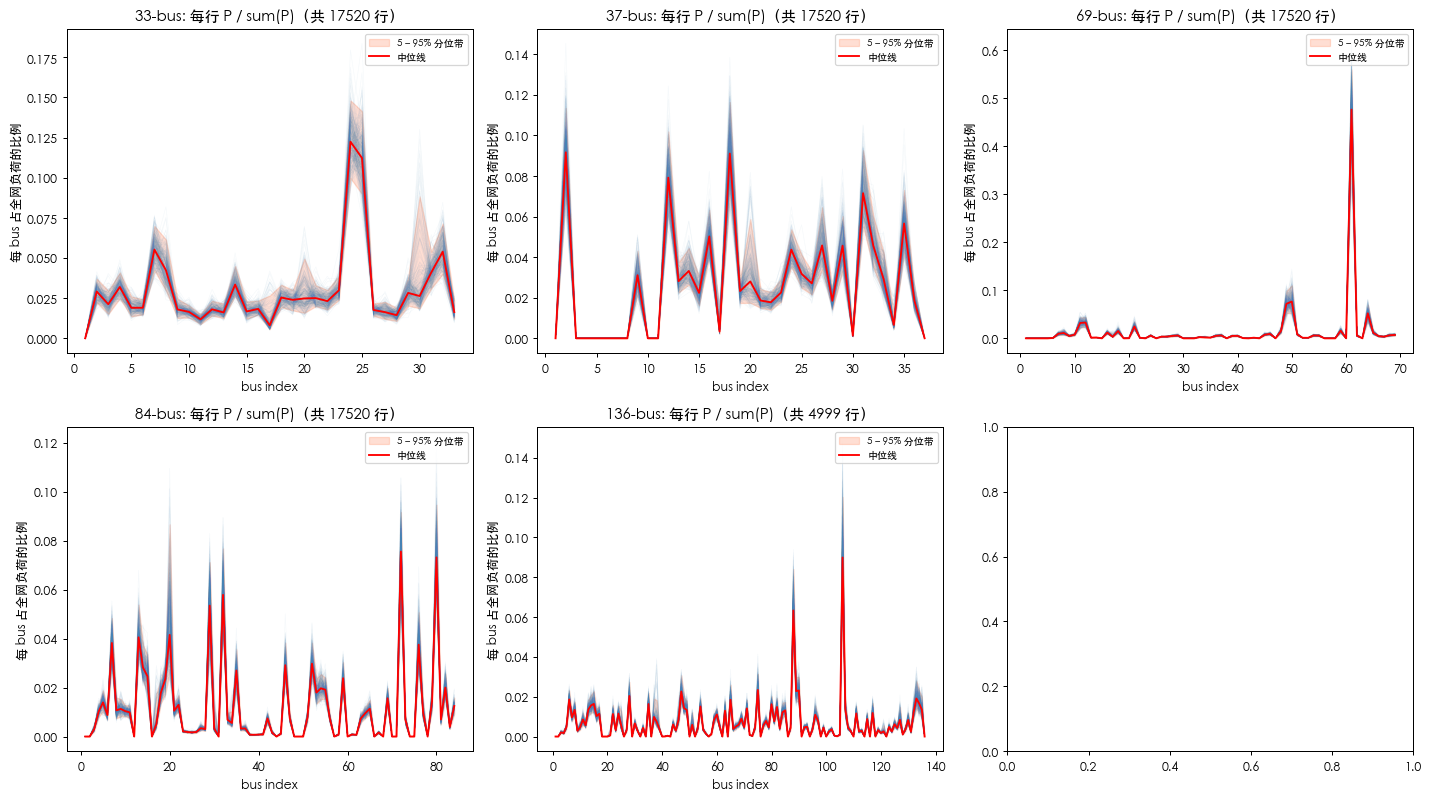


=== 数值指标：每个网络上 shape 的剩余波动 ===

network  原始 P CoV 中位  shape CoV 中位  比值 (shape/raw)             解读
 33-bus        0.327         0.168           0.510 比值越小 → 同比缩放越成立
 37-bus        0.335         0.161           0.495 比值越小 → 同比缩放越成立
 69-bus        0.318         0.203           0.625 比值越小 → 同比缩放越成立
 84-bus        0.326         0.163           0.521 比值越小 → 同比缩放越成立
136-bus        0.356         0.179           0.504 比值越小 → 同比缩放越成立

如何读这张表（用每个 bus 的中位 CoV）:
  - 原始 P CoV: 每个 bus 自己负荷的相对波动（含 scale + shape）
  - shape CoV: 除掉 scale 之后该 bus 占比的相对波动
  - 比值: shape CoV / 原始 CoV
       接近 0  → 波动几乎全是 scale (同比缩放假设成立)
       接近 1  → 除掉 scale 后波动没消，shape 也在大变
       0.3 左右 → 大约 70% 的波动是 scale、30% 是 shape


In [12]:
# 跨 5 个网络做 scale-vs-shape 分解，每个网络一张子图
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
rng = np.random.default_rng(7)

shape_summary_rows = []  # 收集每个网络的数值指标

for ax, n_bus in zip(axes, NETWORKS):
    df_n, P_n, _ = load_network(n_bus)

    # total_P 是每行的负荷之和；axis=1 不写 keepdims 后面广播也行，但显式更安全
    total = P_n.sum(axis=1, keepdims=True)  # (rows, 1)
    # 排除 total=0 行（应该没有，保险）
    valid = (total[:, 0] > 1e-9)
    shape = P_n[valid] / total[valid]       # (rows, n_bus)

    # 抽 300 条画淡线（视觉直观感受窄/宽）
    n_show = min(300, shape.shape[0])
    idx_show = rng.choice(shape.shape[0], size=n_show, replace=False)
    for i in idx_show:
        ax.plot(np.arange(1, n_bus + 1), shape[i], color='steelblue', alpha=0.05, linewidth=0.5)

    # 分位包络带
    p05 = np.percentile(shape, 5, axis=0)
    p50 = np.percentile(shape, 50, axis=0)
    p95 = np.percentile(shape, 95, axis=0)
    x = np.arange(1, n_bus + 1)
    ax.fill_between(x, p05, p95, color='coral', alpha=0.25, label='5–95% 分位带')
    ax.plot(x, p50, color='red', linewidth=1.5, label='中位线')

    ax.set_title(f'{n_bus}-bus: 每行 P / sum(P)（共 {shape.shape[0]} 行）')
    ax.set_xlabel('bus index')
    ax.set_ylabel('每 bus 占全网负荷的比例')
    ax.legend(fontsize=8, loc='upper right')

    # === 量化指标：每个 bus 的 shape 还残留多少波动 ===
    # 排除 slack bus（shape 恒为 0）
    nonzero_bus = (shape.mean(axis=0) > 1e-9)
    shape_mean = shape[:, nonzero_bus].mean(axis=0)
    shape_std = shape[:, nonzero_bus].std(axis=0)
    shape_cov = shape_std / shape_mean

    # 原始 P 的 CoV（每 bus）
    P_mean = P_n[:, nonzero_bus].mean(axis=0)
    P_std = P_n[:, nonzero_bus].std(axis=0)
    P_cov = P_std / P_mean

    # shape CoV / raw CoV 比值 = 形状变化 占 原始变化 的比例
    # 越小说明波动主要被 total_P 吸收了（= scale 主导）
    ratio = shape_cov / P_cov

    shape_summary_rows.append({
        'network': f'{n_bus}-bus',
        '原始 P CoV 中位': round(np.median(P_cov), 3),
        'shape CoV 中位': round(np.median(shape_cov), 3),
        '比值 (shape/raw)': round(np.median(ratio), 3),
        '解读': '比值越小 → 同比缩放越成立',
    })

plt.tight_layout()
plt.show()

print('\n=== 数值指标：每个网络上 shape 的剩余波动 ===\n')
summary = pd.DataFrame(shape_summary_rows)
print(summary.to_string(index=False))

print()
print('如何读这张表（用每个 bus 的中位 CoV）:')
print('  - 原始 P CoV: 每个 bus 自己负荷的相对波动（含 scale + shape）')
print('  - shape CoV: 除掉 scale 之后该 bus 占比的相对波动')
print('  - 比值: shape CoV / 原始 CoV')
print('       接近 0  → 波动几乎全是 scale (同比缩放假设成立)')
print('       接近 1  → 除掉 scale 后波动没消，shape 也在大变')
print('       0.3 左右 → 大约 70% 的波动是 scale、30% 是 shape')

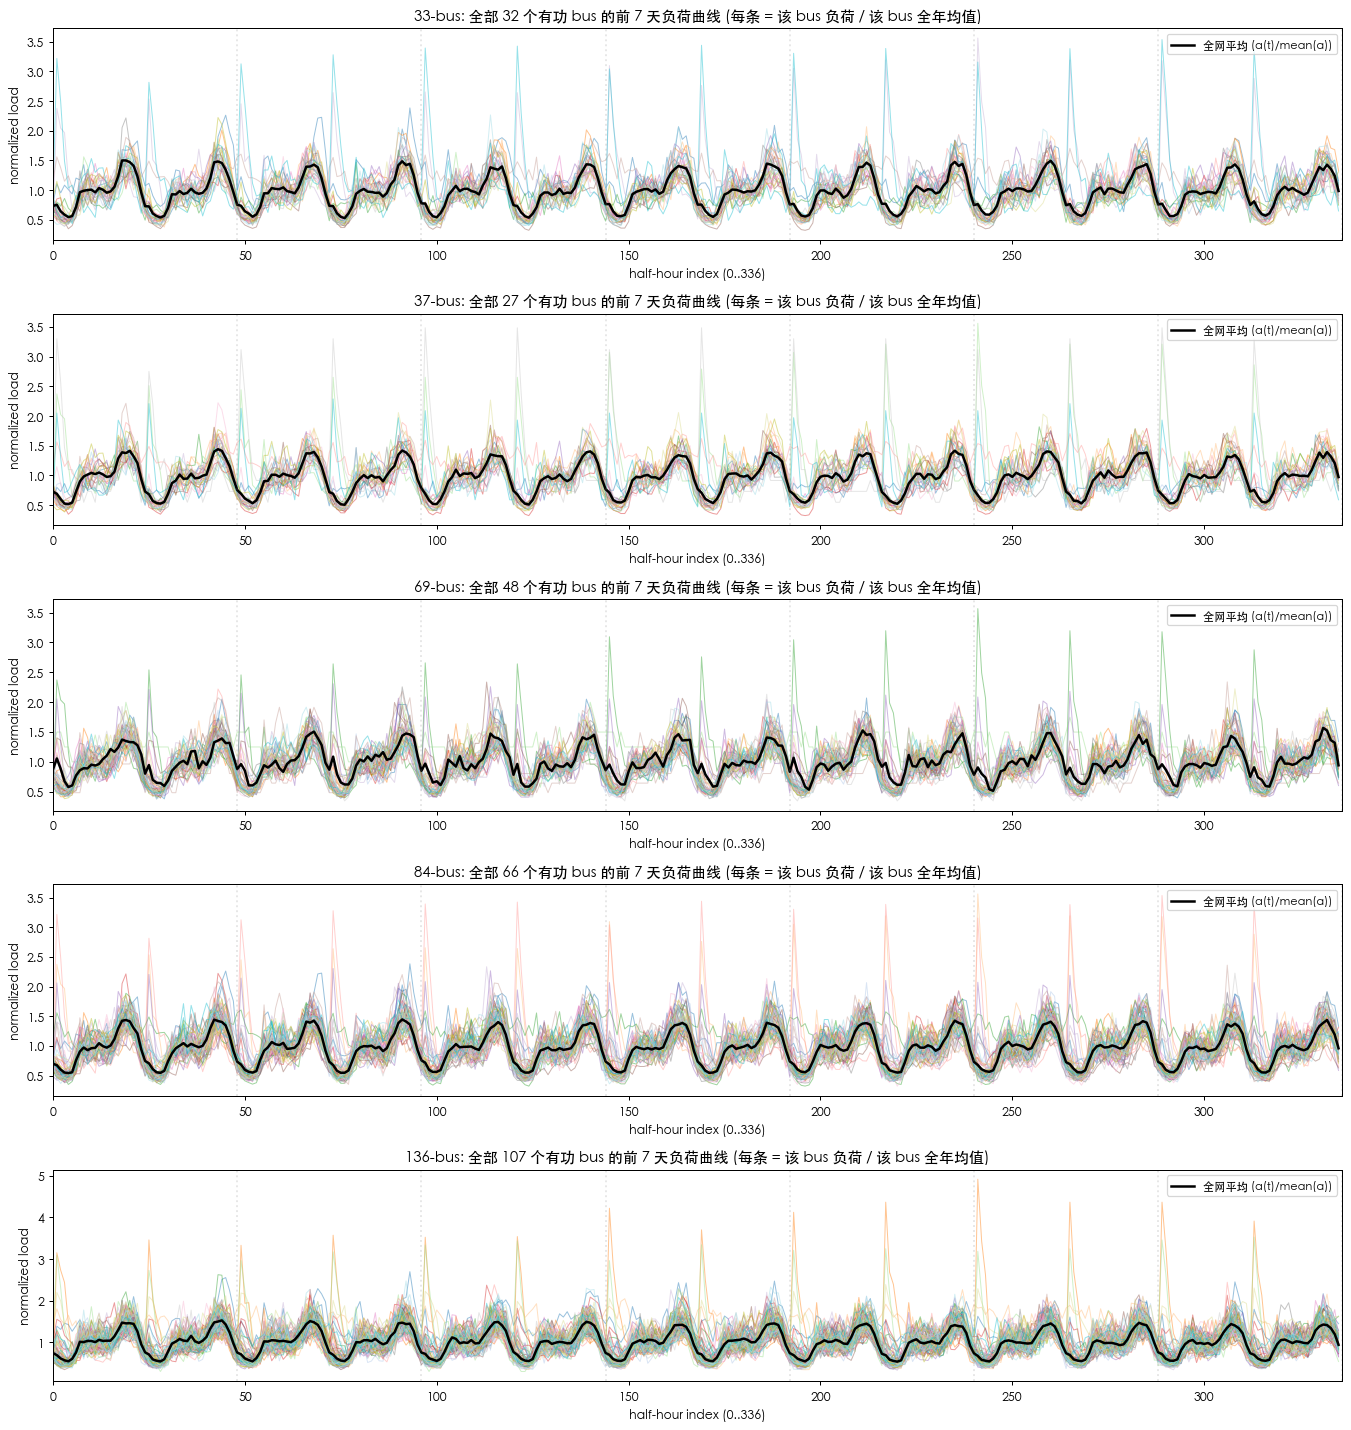

如何读这张图:
  - 如果所有彩色细线完全跟黑色粗线重合 → 是纯等比缩放 (所有 bus 同步起伏)
  - 如果彩色细线整体跟随黑色粗线、但有明显上下散布 → 部分等比缩放 + 形状扰动
  - 如果彩色细线各走各的、跟黑线无关 → 没有等比缩放关系

对应的数值指标 (从上面的 shape/raw 比值表):
  比值 ≈ 0   ↔ 上图完全重合
  比值 ≈ 0.5 ↔ 上图有可见散布 (50% 的波动是形状变化)
  比值 ≈ 1   ↔ 上图各走各的


In [13]:
# === 等比缩放的"目视检验": 每个 bus 自己的时间曲线，全除以自己的均值后叠加 ===
#
# 原理: 如果 load_i(t) = α(t) * base_i (纯等比缩放),
#       则 load_i(t) / mean(load_i) = α(t) / mean(α), 跟 bus i 无关.
#       于是所有 bus 的归一化曲线应该完全重合成一条.
#
# 画前 7 天 (= 336 个半小时)，所有 bus 全画出来。

WINDOW = 7 * 48  # 前 7 天

fig, axes = plt.subplots(5, 1, figsize=(15, 16))

for ax, n_bus in zip(axes, NETWORKS):
    _, P_n, _ = load_network(n_bus)
    P_window = P_n[:WINDOW]  # (336, n_bus)

    # 排除 slack 和任何均值为 0 的 bus，否则除零
    bus_mean = P_n.mean(axis=0)  # 用全年均值更稳，不是窗口内均值
    valid_bus = bus_mean > 1e-9
    P_norm = P_window[:, valid_bus] / bus_mean[valid_bus]  # (336, n_valid_bus)
    n_valid = P_norm.shape[1]

    # 全部 bus 一起画，每条颜色不同 + 半透明
    cmap = plt.cm.tab20(np.linspace(0, 1, n_valid))
    for bus_idx in range(n_valid):
        ax.plot(P_norm[:, bus_idx], color=cmap[bus_idx], alpha=0.45, linewidth=0.8)

    # 同时画"全网平均的归一化曲线"作参考 (= α(t)/mean(α))
    total = P_n[:, valid_bus].sum(axis=1)
    total_norm = total[:WINDOW] / total.mean()
    ax.plot(total_norm, color='black', linewidth=2.0, label=f'全网平均 (α(t)/mean(α))')

    # 标日界
    for d in range(8):
        ax.axvline(d * 48, color='gray', alpha=0.2, linestyle=':')

    ax.set_title(f'{n_bus}-bus: 全部 {n_valid} 个有功 bus 的前 7 天负荷曲线 '
                 f'(每条 = 该 bus 负荷 / 该 bus 全年均值)')
    ax.set_xlabel('half-hour index (0..336)')
    ax.set_ylabel('normalized load')
    ax.legend(loc='upper right', fontsize=9)
    ax.set_xlim(0, WINDOW)

plt.tight_layout()
plt.show()

print('如何读这张图:')
print('  - 如果所有彩色细线完全跟黑色粗线重合 → 是纯等比缩放 (所有 bus 同步起伏)')
print('  - 如果彩色细线整体跟随黑色粗线、但有明显上下散布 → 部分等比缩放 + 形状扰动')
print('  - 如果彩色细线各走各的、跟黑线无关 → 没有等比缩放关系')
print()
print('对应的数值指标 (从上面的 shape/raw 比值表):')
print('  比值 ≈ 0   ↔ 上图完全重合')
print('  比值 ≈ 0.5 ↔ 上图有可见散布 (50% 的波动是形状变化)')
print('  比值 ≈ 1   ↔ 上图各走各的')

## 跨网络规模的简要对比

回顾上一轮 split 审计的发现：
- 33-bus: 87 种拓扑
- 37-bus: 92 种
- 69-bus: 47 种
- 84-bus: ~5700 种
- 136-bus: ~1666 种（每行一种）

现在加上每个网络的「**负荷压缩比**」 = `行数 / 拓扑数`，看每种网络规模上"一种拓扑平均要服务多少种负荷"。

In [14]:
rows = []
for n in NETWORKS:
    df, P, Q = load_network(n)
    df = df.copy()
    df['topo'] = df['updated_open_lines'].apply(canonical_open_lines)
    n_topo = df['topo'].nunique()
    total_P = P.sum(axis=1)
    rows.append({
        'network': f'{n}-bus',
        'n_rows': len(df),
        'n_topo': n_topo,
        'rows_per_topo': round(len(df) / n_topo, 1),
        'total_P_mean': round(total_P.mean(), 3),
        'total_P_std': round(total_P.std(), 3),
        'total_P_peak/trough': round(total_P.max() / total_P.min(), 2),
    })
print(pd.DataFrame(rows).to_string(index=False))

network  n_rows  n_topo  rows_per_topo  total_P_mean  total_P_std  total_P_peak/trough
 33-bus   17520      17         1030.6         1.771        0.477                 3.86
 37-bus   17520      13         1347.7         0.361        0.099                 3.80
 69-bus   17520      14         1251.4         1.650        0.391                 4.15
 84-bus   17520     389           45.0        14.042        3.778                 3.65
136-bus    4999     625            8.0         8.750        2.577                 3.25


## 总结

（运行完上面所有 cell 后看打印结果填这一段。）

### 验证清单

- [ ] 每 bus 的 P_mean 在不同 bus 间差异显著（即每个 bus 有不同的基准负荷）
- [ ] 每 bus 的 P_CoV 在不同 bus 间也不同（即每个 bus 有不同的住户群曲线，而非全网共享一条曲线）
- [ ] 前 7 天曲线呈现清晰的日周期，hour-of-day pattern 有 2-3× 的峰谷比
- [ ] 365 天日均值呈现年周期（冬高夏低或类似形态）
- [ ] 节点间相关性均值 ~0.7-0.9（验证"共享日周期"）
- [ ] Top 10 拓扑覆盖率（如果 >50%，说明长尾很短；如果 <30%，说明拓扑相对均匀分布）
- [ ] PCA 散点按拓扑染色后呈现块状区域（说明拓扑切换由"负荷形状"决定）

### 解读

**33/37/69-bus 拓扑只有几十种的根本原因**：
- 网络规模小 → 可行 radial topology 总数有限（拓扑空间本身就小）
- 负荷形状的扰动幅度，相对于网络尺寸，只能让最优解在少数几个相邻拓扑之间切换

**对模型评测的影响**：
- 这些小网络上「分类到正确拓扑桶」的难度远低于「构造拓扑组合」
- 84/136-bus 才能体现"组合搜索"的难度 —— 后续 RL 主要看大网络指标